In [6]:
import os
import sys
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import random
import numpy as np

# Add the directory containing 'hamiltonian' to the Python path
sys.path.append('/home/scostagonza/Documents/ETC/Effective-Topological-Coverage-ETC/examples/etc_utils')

from etc_utils.hamiltonian import precompute, H, mu_density_aware, gamma_balancer

In [7]:
def random_subsets(nodes, k, iters, seed=1):
    """
    Yield `iters` random subsets of size `k` from the list of `nodes`.

    Parameters
    ----------
    nodes : list
        List of nodes to sample from.
    k : int
        Size of each subset.
    iters : int
        Number of subsets to generate.
    seed : int
        Random seed for reproducibility.

    Yields
    ------
    list of int
        Randomly sampled indices (or node IDs).
    """
    rng = random.Random(seed)
    nodes = list(nodes)
    for _ in range(iters):
        yield rng.sample(nodes, k)

In [8]:
graph_dir = "/home/scostagonza/Documents/ETC/Effective-Topological-Coverage-ETC/examples/data" 
graph_files = [f for f in os.listdir(graph_dir) if f.endswith(".gml")]

print(f"Found {len(graph_files)} graphs:")
for f in graph_files:
    print(" -", f)

Found 14 graphs:
 - WS_beta1.0.gml
 - WS_beta0.0.gml
 - Powerlaw-Cluster.gml
 - WS_beta0.2.gml
 - Starn400.gml
 - d-Regularn400_d6.gml
 - Balanced_Treer3_h5.gml
 - Lollipopc30__t50.gml
 - Core-Periphery.gml
 - Pathn300.gml
 - Geometricn400_r0.07.gml
 - Barbellc25__p5.gml
 - String_of_Pearlsm7_c8.gml
 - BAn400_m2.gml


In [9]:
def evaluate_graph(G, name, k, iters=300, seed=1):
    A, Dinv2, nodes, idx = precompute(G)
    mu = mu_density_aware(G)
    gamma = gamma_balancer(G, mu=mu)

    Hs, T1s, T2s = [], [], []
    rng = np.random.default_rng(seed)
    n = len(nodes)

    for _ in range(iters):
        S_idx = rng.choice(n, size=k, replace=False)
        h, t1, t2 = H(A, Dinv2, S_idx, mu=mu, gamma=gamma)
        Hs.append(h)
        T1s.append(abs(t1))
        T2s.append(t2)

    Hs = np.array(Hs)
    H_norm = (Hs - Hs.min()) / (Hs.max() - Hs.min())

    return {
        "graph": name,
        "n": n,
        "e": G.number_of_edges(),
        "k": k,
        "mu": mu,
        "gamma": gamma,
        "H_mean": Hs.mean(),
        "H_std": Hs.std(),
        "H_min": Hs.min(),
        "H_max": Hs.max(),
        "T1_mean": np.mean(T1s),
        "T2_mean": np.mean(T2s),
        "H_norm_mean": H_norm.mean(),
        "H_norm_std": H_norm.std()
    }

In [10]:
k = 30
results = []

for fname in graph_files:
    path = os.path.join(graph_dir, fname)
    G = nx.read_gml(path)
    G = nx.convert_node_labels_to_integers(G)

    if len(G) >= k:
        res = evaluate_graph(G, name=fname.replace(".gml", ""), k=k)
        results.append(res)
    else:
        print(f"Skipping graph {fname} as it has fewer nodes ({len(G)}) than k ({k}).")

df = pd.DataFrame(results)

Skipping graph Pathn300.gml as it has fewer nodes (20) than k (30).


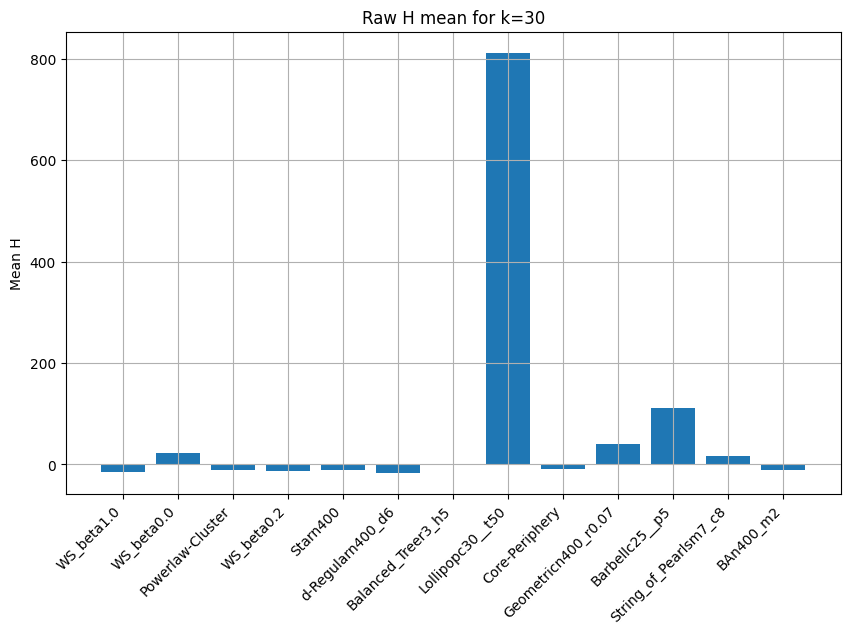

In [11]:
plt.figure(figsize=(10,6))
plt.bar(df["graph"], df["H_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean H")
plt.title(f"Raw H mean for k={k}")
plt.grid(True)
plt.show()


In [12]:
df

,graph,n,e,k,mu,gamma,H_mean,H_std,H_min,H_max,T1_mean,T2_mean,H_norm_mean,H_norm_std
0,WS_beta1.0,150,600,30,0.946309,0.172259,-14.416038,3.898136,-29.127971,-0.535347,21.941745,7.525707,0.514536,0.136334
1,WS_beta0.0,150,600,30,0.946309,2.432863,23.287381,6.296868,3.516581,41.716195,22.143624,45.431005,0.517565,0.164841
2,Powerlaw-Cluster,100,196,30,0.960404,0.164590,-10.354897,5.600071,-29.273363,3.523605,16.326869,5.971972,0.576836,0.170750
3,WS_beta0.2,150,600,30,0.946309,0.237071,-13.781630,3.622302,-24.892269,-5.375919,22.411745,8.630115,0.569299,0.185603
4,Starn400,51,50,30,0.960784,0.071009,-10.723220,13.520424,-25.199897,4.952898,14.953007,4.229787,0.480111,0.448397
5,d-Regularn400_d6,100,300,30,0.939394,0.213485,-16.299666,3.357992,-26.837866,-7.093217,25.257172,8.957506,0.533724,0.170071
6,Balanced_Treer3_h5,364,363,30,0.994505,0.177274,-1.143780,1.289916,-4.789269,1.096787,2.161392,1.017612,0.619343,0.219148
7,Lollipopc30__t50,80,485,30,0.846519,23.873397,812.223579,275.874542,276.761098,2509.229720,55.585258,867.808837,0.239852,0.123574
8,Core-Periphery,300,1625,30,0.963768,0.120620,-9.711050,5.016373,-27.981018,3.125176,14.604300,4.893250,0.587342,0.161266
9,Geometricn400_r0.07,100,115,30,0.976768,5.709926,40.832800,12.537032,10.754051,79.186363,9.959774,50.792574,0.439540,0.183203


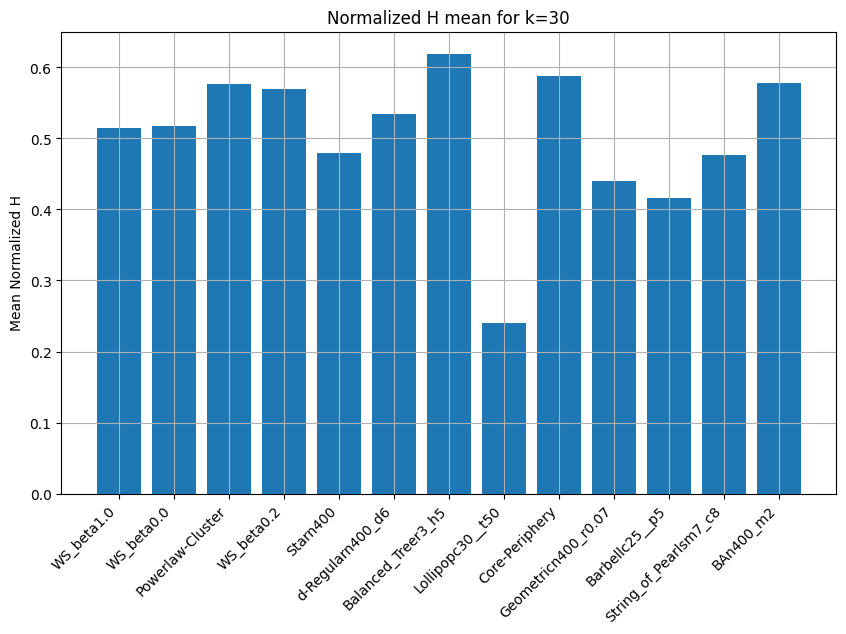

In [13]:
plt.figure(figsize=(10,6))
plt.bar(df["graph"], df["H_norm_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Normalized H")
plt.title(f"Normalized H mean for k={k}")
plt.grid(True)
plt.show()

In [14]:
import networkx.algorithms.community as nxcom

def mean_pairwise_distance(G, S):
    dist = dict(nx.all_pairs_shortest_path_length(G))
    nodes = list(S)
    total = 0
    c = 0
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            total += dist[nodes[i]][nodes[j]]
            c += 1
    return total / c if c else 0.0

def communities_touched(G, S):
    parts = list(nxcom.label_propagation_communities(G))
    label = {u: i for i, comm in enumerate(parts) for u in comm}
    return len(set(label[u] for u in S if u in label))

In [15]:
import networkx as nx
G = nx.barbell_graph(100, 50)
G = nx.convert_node_labels_to_integers(G)

A, Dinv2, nodes, idx = precompute(G)
mu = mu_density_aware(G)
gamma = gamma_balancer(G, mu=mu)

In [16]:
k_values = [10, 20, 30, 40, 50]
results = []

for k in k_values:
    for S_idx in random_subsets(nodes, k, iters=200, seed=42):
        h_val, t1, t2 = H(A, Dinv2, S_idx, mu=mu, gamma=gamma)
        mpd = mean_pairwise_distance(G, S_idx)
        ct = communities_touched(G, S_idx)

        results.append({
            "k": k,
            "H": h_val,
            "T1": t1,
            "T2": t2,
            "mean_pairwise_dist": mpd,
            "communities": ct
        })

df = pd.DataFrame(results)

In [17]:
from scipy.stats import spearmanr

print("Correlation between H and MPD:", spearmanr(df["H"], df["mean_pairwise_dist"]).correlation)
print("Correlation between H and communities:", spearmanr(df["H"], df["communities"]).correlation)


Correlation between H and MPD: -0.1734825172230073
Correlation between H and communities: 0.711203237631895


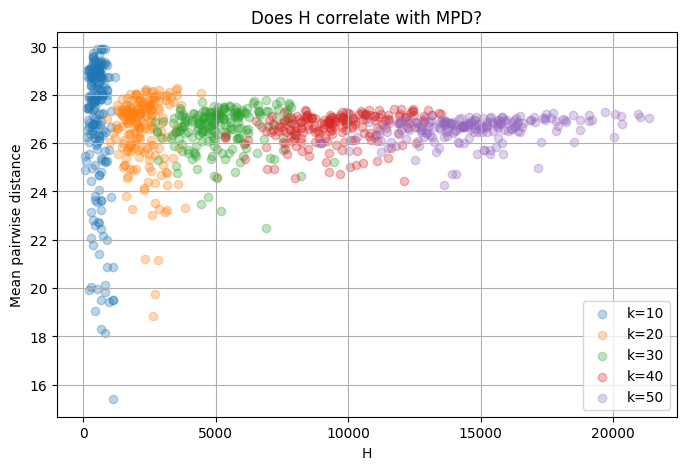

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
for k in k_values:
    df_k = df[df["k"] == k]
    plt.scatter(df_k["H"], df_k["mean_pairwise_dist"], alpha=0.3, label=f"k={k}")
plt.xlabel("H")
plt.ylabel("Mean pairwise distance")
plt.legend()
plt.title("Does H correlate with MPD?")
plt.grid(True)
plt.show()

In [19]:
df

,k,H,T1,T2,mean_pairwise_dist,communities
0,10,821.823326,-16.326940,838.150266,25.266667,2
1,10,450.208942,-8.163470,458.372411,29.222222,4
2,10,454.131055,-8.163470,462.294525,28.844444,4
3,10,379.427842,-6.122602,385.550444,28.288889,5
4,10,523.488124,-10.884627,534.372751,28.844444,3
...,...,...,...,...,...,...
995,50,15608.503580,-246.944964,15855.448544,26.693061,12
996,50,18109.057163,-304.089253,18413.146416,27.003265,9
997,50,15639.637598,-308.170988,15947.808586,26.791837,9
998,50,15255.941365,-264.632482,15520.573847,26.475918,12


In [ ]:
from scipy.stats import spearmanr
rho1 = spearmanr(df["H"], df["mean_pairwise_dist"]).correlation
rho2 = spearmanr(df["H"], df["communities"]).correlation

<Axes: xlabel='k', ylabel='H'>

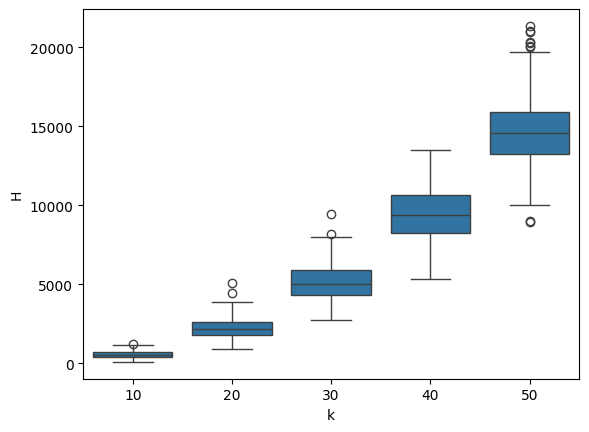

In [ ]:
import seaborn as sns
sns.boxplot(data=df, x="k", y="H")

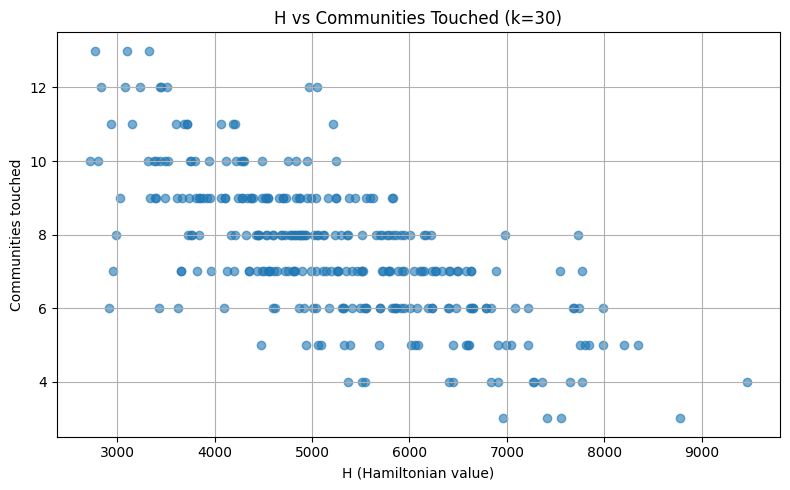

In [ ]:
# Parameters
k = 30
iters = 300
H_vals = []
comm_vals = []

for S in random_subsets(nodes, k, iters=iters, seed=42):
    h_val, *_ = H(A, Dinv2, S, mu=mu, gamma=gamma)
    H_vals.append(h_val)
    comm_vals.append(communities_touched(G, S))

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(H_vals, comm_vals, alpha=0.6)
plt.xlabel("H (Hamiltonian value)")
plt.ylabel("Communities touched")
plt.title(f"H vs Communities Touched (k={k})")
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
corr = spearmanr(-1 * np.array(H_vals), np.array(comm_vals)).correlation
print(f"Spearman correlation: {corr:.3f}")

Spearman correlation: 0.691


In [ ]:
def get_min_max_H_subsets(G, k=30, iters=300, seed=42):
    A, Dinv2, nodes, idx = precompute(G)
    mu = mu_density_aware(G)
    gamma = gamma_balancer(G, mu=mu)

    rng = np.random.default_rng(seed)
    n = len(nodes)
    
    best_subset = None
    worst_subset = None
    H_min = np.inf
    H_max = -np.inf

    for _ in range(iters):
        S_idx = rng.choice(n, size=k, replace=False)
        h_val, _, _ = H(A, Dinv2, S_idx, mu=mu, gamma=gamma)

        if h_val < H_min:
            H_min = h_val
            best_subset = S_idx

        if h_val > H_max:
            H_max = h_val
            worst_subset = S_idx

    return list(best_subset), list(worst_subset), H_min, H_max

In [ ]:
for fname in graph_files:
    path = os.path.join(graph_dir, fname)
    G = nx.read_gml(path)
    G = nx.convert_node_labels_to_integers(G)

    if len(G) >= k:  # Ensure the graph has at least k nodes
        best_S, worst_S, Hmin, Hmax = get_min_max_H_subsets(G, k=30)
        print(f"Graph: {fname}")
        print("Best (min H):", best_S)
        print("Worst (max H):", worst_S)
        print("H_min =", Hmin, ", H_max =", Hmax)
    else:
        print(f"Skipping graph {fname} as it has fewer nodes ({len(G)}) than k ({k}).")

Graph: WS_beta1.0.gml
Best (min H): [np.int64(132), np.int64(21), np.int64(43), np.int64(116), np.int64(71), np.int64(134), np.int64(87), np.int64(119), np.int64(54), np.int64(20), np.int64(26), np.int64(100), np.int64(69), np.int64(72), np.int64(51), np.int64(112), np.int64(42), np.int64(113), np.int64(23), np.int64(66), np.int64(99), np.int64(120), np.int64(14), np.int64(45), np.int64(25), np.int64(29), np.int64(97), np.int64(38), np.int64(104), np.int64(64)]
Worst (max H): [np.int64(112), np.int64(9), np.int64(31), np.int64(120), np.int64(46), np.int64(47), np.int64(137), np.int64(23), np.int64(79), np.int64(65), np.int64(149), np.int64(115), np.int64(145), np.int64(17), np.int64(105), np.int64(82), np.int64(94), np.int64(45), np.int64(133), np.int64(91), np.int64(62), np.int64(93), np.int64(51), np.int64(41), np.int64(102), np.int64(61), np.int64(14), np.int64(142), np.int64(25), np.int64(144)]
H_min = -26.51393898592906 , H_max = -3.9867514662935033
Graph: WS_beta0.0.gml
Best (min